In [61]:
import os
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pathlib import Path
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

env_path = Path('.') / 'france_travail.env'
load_dotenv(dotenv_path=env_path)

CLIENT_ID = os.getenv("FRANCETRAVAIL_CLIENT_ID")
CLIENT_SECRET = os.getenv("FRANCETRAVAIL_CLIENT_SECRET")

In [62]:
def get_france_travail_token(client_id, client_secret):
    url = "https://entreprise.francetravail.fr/connexion/oauth2/access_token?realm=/partenaire"
    data = {"grant_type": "client_credentials", "client_id": client_id, 
            "client_secret": client_secret, "scope": "o2dsoffre api_offresdemploiv2"}
    headers = {"Content-Type": "application/x-www-form-urlencoded"}
    
    response = requests.post(url, data=data, headers=headers, timeout=10)
    return response.json().get("access_token") if response.status_code == 200 else None

In [63]:
access_token = get_france_travail_token(CLIENT_ID, CLIENT_SECRET)

if access_token:
    print("Autorisation réussie")
else:
    print("Échec de l'obtention du token")

Autorisation réussie


In [64]:
def search_job_offers(token, keyword=None, department=None, limit=100):
    url = "https://api.francetravail.io/partenaire/offresdemploi/v2/offres/search"
    headers = {"Authorization": f"Bearer {token}"}
    all_offers, start = [], 0
    
    while len(all_offers) < limit:
        params = {"range": f"{start}-{start+149}", "sort": 0}
        if keyword: params["motsCles"] = keyword
        if department: params["departement"] = department
        
        r = requests.get(url, headers=headers, params=params, timeout=10)
        if r.status_code not in [200, 206]: break
        
        batch = r.json().get("resultats", r.json())
        all_offers.extend(batch)
        if len(batch) < 150: break
        start += 150
        time.sleep(0.5)
    
    return all_offers[:limit]

In [65]:
# Collecte de 1000 offres (peut être augmenté jusqu'à 500, mais plus long)
job_offers = search_job_offers(access_token, limit=1000)

# Sauvegarde des données brutes
with open('raw_jobs.json', 'w', encoding='utf-8') as f:
    json.dump(job_offers, f, ensure_ascii=False, indent=2)
print("Données brutes sauvegardées dans raw_jobs.json")

Données brutes sauvegardées dans raw_jobs.json


In [66]:
# Conversion en DataFrame
df_raw = pd.DataFrame(job_offers)

# Extraction des champs clés
def extract_info(row):
    info = {
        'id': row.get('id', ''),
        'titre': row.get('intitule', ''),
        'description': row.get('description', ''),
        'entreprise': row.get('entreprise', {}).get('nom', '') if isinstance(row.get('entreprise'), dict) else '',
        'lieu': row.get('lieuTravail', {}).get('libelle', '') if isinstance(row.get('lieuTravail'), dict) else '',
        'contrat': row.get('typeContrat', ''),
        'date_creation': row.get('dateCreation', '')
    }
    return pd.Series(info)

df = df_raw.apply(extract_info, axis=1)
df['texte_complet'] = df['titre'] + " " + df['description']

print(f"Taille du dataset: {df.shape}")
print("\nPremiers 3 enregistrements:")
df.head(3)

Taille du dataset: (1000, 8)

Premiers 3 enregistrements:


,id,titre,description,entreprise,lieu,contrat,date_creation,texte_complet
0,205LJBP,Commis de salle (H/F),Rejoignez l'aventure de L'Abbaye de Villeneuve...,ABBAYE DE VILLENEUVE,44 - LES SORINIERES,CDI,2026-03-15T19:33:25.422Z,Commis de salle (H/F) Rejoignez l'aventure de ...
1,205LJBN,Responsable Chiffrage Projets tuyauterie (H/F),"One Tilt, cabinet de recrutement et d'intérim,...",ONE TILT,60 - Compiègne,CDI,2026-03-15T19:32:20.667Z,Responsable Chiffrage Projets tuyauterie (H/F)...
2,205LJBM,Educateur Jeune Enfant (H/F),Les Petits Héros Mérignac recherche une EJE.\n...,PISSENLITS ET ORCHIDEES,33 - MERIGNAC,CDI,2026-03-15T19:31:19.176Z,Educateur Jeune Enfant (H/F) Les Petits Héros ...


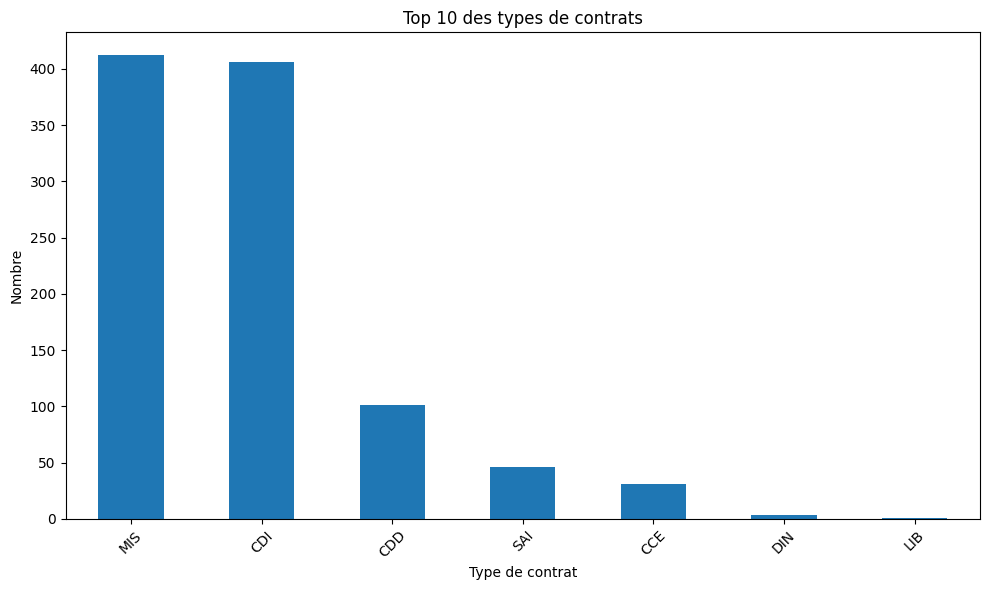

In [67]:
plt.figure(figsize=(10,6))
df['contrat'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 des types de contrats')
plt.xlabel('Type de contrat')
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
def suggest_category(title, desc):
    text = (str(title) + " " + str(desc)).lower()
    
    white_keywords = ['ingénieur', 'cadre', 'manager', 'directeur', 'consultant',
        'responsable', 'chef de projet', 'architecte', 'expert', 'stratège',
        'développeur', 'analyste', 'data scientist', 'chercheur']
    blue_keywords = ['ouvrier', 'manœuvre', 'manutentionnaire', 'opérateur',
        'conducteur', 'préparateur', 'agent de propreté', 'maçon',
        'peintre', 'chauffeur', 'électricien', 'plombier']
    grey_keywords = ['technicien', 'assistant', 'coordinateur', 'superviseur',
        'contrôleur', 'agent de maîtrise', 'chef d\'équipe',
        'inspecteur', 'régleur', 'métreur', 'animateur', 'planificateur']
    
    score_white = sum(1 for kw in white_keywords if kw in text)
    score_blue = sum(1 for kw in blue_keywords if kw in text)
    score_grey = sum(1 for kw in grey_keywords if kw in text)
    
    if score_white > score_blue and score_white > score_grey:
        return 'white-collar'
    elif score_blue > score_white and score_blue > score_grey:
        return 'blue-collar'
    elif score_grey > score_white and score_grey > score_blue:
        return 'grey-collar'
    else:
        return 'uncertain'

# Application
df['categorie_suggeree'] = df.apply(lambda r: suggest_category(r['titre'], r['description']), axis=1)

print("Distribution par catégorie:")
print(df['categorie_suggeree'].value_counts())

Distribution par catégorie:
categorie_suggeree
uncertain       508
white-collar    329
blue-collar     107
grey-collar      56
Name: count, dtype: int64


In [69]:
df.to_csv('job_offers_annotated.csv', index=False, encoding='utf-8')

# Quelques exemples
df[['titre', 'categorie_suggeree']].head(10)

,titre,categorie_suggeree
0,Commis de salle (H/F),white-collar
1,Responsable Chiffrage Projets tuyauterie (H/F),white-collar
2,Educateur Jeune Enfant (H/F),uncertain
3,"Chargé(e) d'affaires maintenance tuyauterie, c...",white-collar
4,Project Manager / Chef(fe) de projet tuyauteri...,white-collar
5,Réceptionniste polyvalent(e) tournant(e) 24h/s...,uncertain
6,Conducteur de travaux VRD (H/F),white-collar
7,Chargé d'études de Prix VRD (H/F),white-collar
8,Chargé d'études de Prix VRD (H/F),white-collar
9,Ref NA IMS INGENIEUR DEBUTANT MISE en SERVIC...,white-collar


In [70]:
from sklearn.model_selection import train_test_split
from transformers import CamembertTokenizer, CamembertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Sélection uniquement des données annotées (exclure 'uncertain')
df_clean = df[df['categorie_suggeree'] != 'uncertain'].copy()
print(f"Taille du dataset nettoyé: {len(df_clean)}")

# Encodage des étiquettes
label_map = {'white-collar': 0, 'grey-collar': 1, 'blue-collar': 2}
df_clean['label'] = df_clean['categorie_suggeree'].map(label_map)

# Division en train/test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_clean['texte_complet'].tolist(),
    df_clean['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_clean['label']
)

print(f"Train: {len(train_texts)} exemples")
print(f"Test: {len(test_texts)} exemples")

Taille du dataset nettoyé: 492
Train: 393 exemples
Test: 99 exemples


In [71]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import (
    CamembertTokenizer, 
    CamembertForSequenceClassification,
    Trainer, 
    TrainingArguments, 
    DataCollatorWithPadding
)
import transformers
import os
import torch

os.environ['TENSORBOARD_LOGGING_DIR'] = './logs'
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Définition du modèle
model_name = "camembert-base"
tokenizer = CamembertTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding=True, max_length=512)

# Création du Dataset
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

# Tokenisation des données
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Création du data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Chargement du modèle sur CPU
device = torch.device("cpu")
model = CamembertForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# Paramètres d'entraînement
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    fp16=False,
    use_cpu=True,
    dataloader_num_workers=0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Lancement de l'entraînement
trainer.train()

Loading weights: 100%|██████████████████████| 197/197 [00:00<00:00, 6233.19it/s]
CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.769885,0.821412,0.666667,0.533333,0.444444,0.666667
2,0.470139,0.588506,0.767677,0.705882,0.690932,0.767677
3,0.396923,0.397490,0.888889,0.887046,0.888471,0.888889


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  3.89it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'rober

TrainOutput(global_step=297, training_loss=0.6563820281012692, metrics={'train_runtime': 1162.173, 'train_samples_per_second': 1.014, 'train_steps_per_second': 0.256, 'total_flos': 310210719501312.0, 'train_loss': 0.6563820281012692, 'epoch': 3.0})

Résultats sur l'ensemble de test:


   Accuracy: 0.8889
   Precision: 0.8885
   Recall: 0.8889
   F1-score: 0.8870


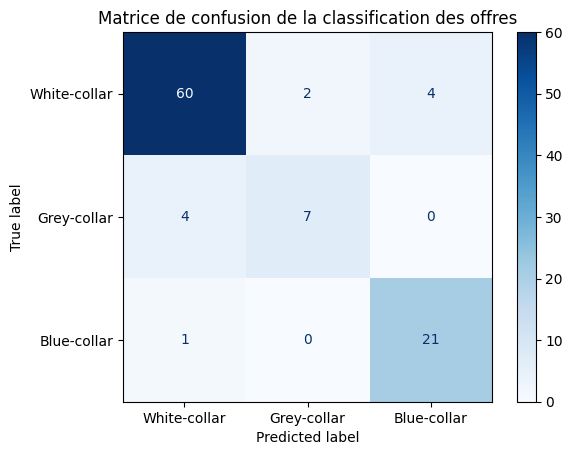

In [72]:
# Évaluation finale
print("Résultats sur l'ensemble de test:")

# Obtention des prédictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"   Accuracy: {acc:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-score: {f1:.4f}")

# Matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['White-collar', 'Grey-collar', 'Blue-collar'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion de la classification des offres')
plt.show()

In [73]:
# Sauvegarde du modèle
model_save_path = "./camembert-job-classifier"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Modèle sauvegardé dans {model_save_path}")

# Conversion inverse des étiquettes
reverse_label_map = {0: 'white-collar', 1: 'grey-collar', 2: 'blue-collar'}

# Création du DataFrame avec les résultats
df_results = pd.DataFrame({
    'texte': test_texts,
    'categorie_reelle': [reverse_label_map[i] for i in y_true],
    'categorie_predite': [reverse_label_map[i] for i in y_pred]
})

df_results.to_csv('classification_results.csv', index=False, encoding='utf-8')
print("Résultats de classification sauvegardés dans classification_results.csv")

metrics = {
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'confusion_matrix': cm.tolist()
}

import json
with open('evaluation_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print("Métriques sauvegardées dans evaluation_metrics.json")

Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  2.01it/s]

Modèle sauvegardé dans ./camembert-job-classifier
Résultats de classification sauvegardés dans classification_results.csv
Métriques sauvegardées dans evaluation_metrics.json


Total des erreurs: 11 sur 99 (11.1%)
Distribution des erreurs par type:
error_type
grey-collar → white-collar    4
white-collar → blue-collar    4
white-collar → grey-collar    2
blue-collar → white-collar    1
Name: count, dtype: int64
exemples d'erreurs (5 premiers):
--------------------------------------------------------------------------------
Texte: Animateur/Animatrice d'activités de loisirs périscolaires (H/F) Nous recrutons actuellement pour compléter notre équipe d'animation sur notre accueil périscolaire situé dans une école privée à La Poss...
Réelle: grey-collar → Prédite: white-collar
----------------------------------------
Texte: Technicien "Monteur / Monteuse de meubles" (H/F) Le Technicien Monteur / Monteuse de meubles est un professionnel spécialisé dans l'assemblage, l'installation et la mise en service de différents types...
Réelle: grey-collar → Prédite: white-collar
----------------------------------------
Texte: Conducteur Poids Lourds (h/f) Adecco Pontarlier re

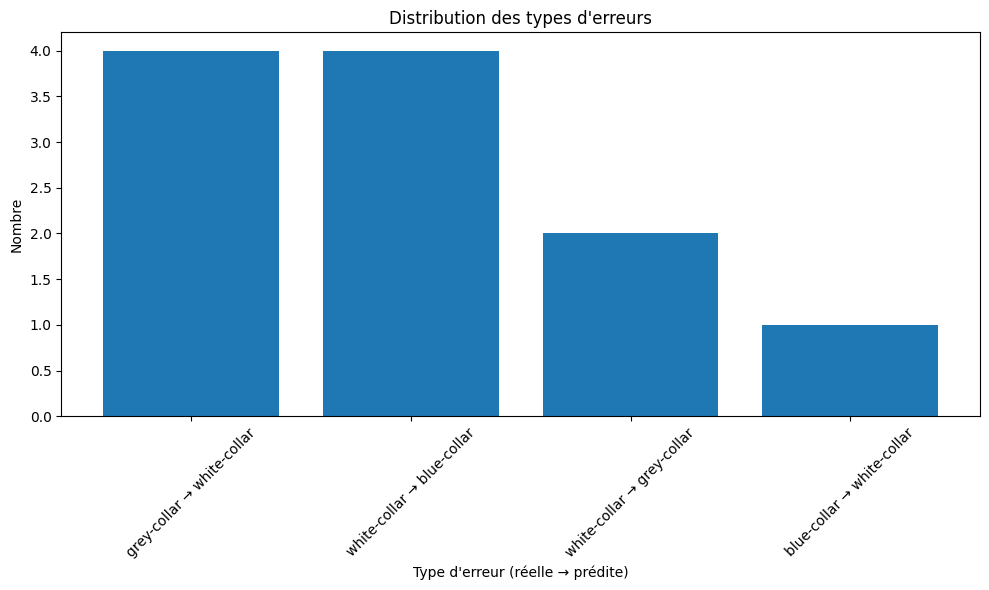

In [74]:
# Recherche des erreurs
errors = df_results[df_results['categorie_reelle'] != df_results['categorie_predite']]
error_rate = len(errors)/len(df_results)*100
print(f"Total des erreurs: {len(errors)} sur {len(df_results)} ({error_rate:.1f}%)")

print("Distribution des erreurs par type:")
# Création de la colonne avec le type d'erreur
errors['error_type'] = errors['categorie_reelle'] + ' → ' + errors['categorie_predite']
print(errors['error_type'].value_counts())

print("exemples d'erreurs (5 premiers):")
print("-" * 80)

for i, row in errors.head(5).iterrows():
    print(f"Texte: {row['texte'][:200]}...")
    print(f"Réelle: {row['categorie_reelle']} → Prédite: {row['categorie_predite']}")
    print("-" * 40)

# Statistiques par classe
print("statistiques par classe:")
print("-" * 40)

from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred, target_names=['white-collar', 'grey-collar', 'blue-collar'])
print(report)

# Visualisation de la distribution des erreurs
plt.figure(figsize=(10, 6))
error_types = errors['error_type'].value_counts()
plt.bar(error_types.index, error_types.values)
plt.title('Distribution des types d\'erreurs')
plt.xlabel("Type d'erreur (réelle → prédite)")
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()